## 📊 Exploratory Data Analysis: Key Insights & Findings

---

### 1. Driver Dominance (Wins & Podiums)
* **All-Time Leaders:** **Lewis Hamilton** leads both total race victories (>100 wins) and podium finishes (>200 podiums), followed closely by **Michael Schumacher**.
* **Modern Era Impact:** Active/modern drivers (**Max Verstappen**, **Sebastian Vettel**, and **Fernando Alonso**) hold top spots across both metrics, demonstrating extended performance runs in modern racing eras with longer calendar seasons.
* **Consistency vs. Pure Wins:** Drivers like **Kimi Räikkönen**, **Rubens Barrichello**, and **Valtteri Bottas** feature prominently in the top 10 for podium finishes despite having lower overall win counts, highlighting consistent top-3 finishing reliability.

---

### 2. Constructor Supremacy
* **Historic Giants:** **Scuderia Ferrari** dominates constructor history with roughly 250 race wins, holding a significant margin over **McLaren** (~185 wins).
* **Modern & Era-Specific Dynasties:** **Mercedes** and **Red Bull Racing** have cemented themselves among the top 4 winningest constructors, overtaking historic powerhouses like **Williams** and **Team Lotus**.

---

### 3. Reliability & Failure Analysis (DNFs)
* **Primary Failure Point (Mechanical):** **Engine failures** are by far the leading cause of race retirements (over 1,850 occurrences), highlighting powertrain reliability as the single most critical mechanical factor in F1 history.
* **Driver & On-Track Incidents:** **Accidents, collisions, and spin-offs** represent the largest cluster of driver- and track-related retirements (combining for over 2,500 DNFs).
* **Secondary Mechanical Bottlenecks:** Drivetrain and mechanical sub-assemblies (**Gearbox, Suspension, and Transmission**) form the second tier of mechanical non-finishes.

---

### 4. Data Pipeline Status
* Successfully merged normalized `statusId` metadata onto the main fact table to decode finish states and DNF causes.
* Cleaned and exported transformed dataset as `fact_race_results.csv` for downstream dimensional modeling and reporting.

# The Python EDA on F1 Dataset

---

## Importing the required libraries

In [1]:
import pandas as pd 
import numpy as np 

In [2]:
result = pd.read_csv('results.csv')

In [3]:
result.head(2)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1


In [4]:
races = pd.read_csv('races.csv')

In [5]:
races.head(2)

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [6]:
drivers = pd.read_csv('drivers.csv')
drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [7]:
constructor = pd.read_csv('constructors.csv')
constructor.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [8]:
status = pd.read_csv('status.csv')
status.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


In [9]:
pit_stop = pd.read_csv('pit_stops.csv')
pit_stop.head()

,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


In [10]:
lap_time = pd.read_csv('lap_times.csv')
lap_time.head()

,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


In [11]:
result.shape

(26759, 18)

In [12]:
print("Lap Times shape:", lap_time.shape)

Lap Times shape: (589081, 6)


In [13]:
pit_stop.shape

(11371, 7)

---

**Check the NULL values**

In [14]:
print("The missing values in result are: ",result.isnull().sum())

The missing values in result are:  resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64


---

# The Master Fact Table

In [15]:
df = result.copy()
df

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,26760,1144,825,210,20,14,16,16,16,0.0,57,\N,\N,57,1,1:25.637,222.002,11
26755,26761,1144,859,215,30,12,17,17,17,0.0,55,\N,\N,52,12,1:28.751,214.212,5
26756,26762,1144,822,15,77,9,\N,R,18,0.0,30,\N,\N,14,19,1:29.482,212.462,130
26757,26763,1144,861,3,43,20,\N,R,19,0.0,26,\N,\N,5,17,1:29.411,212.631,5


In [16]:
df = result.merge(races[['raceId','year','round','circuitId','name']], on=  'raceId', suffixes=('','_race'))
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,name
0,1,18,1,1,22,1,1,1,1,10.0,...,5690616,39,2,1:27.452,218.300,1,2008,1,1,Australian Grand Prix
1,2,18,2,2,3,5,2,2,2,8.0,...,5696094,41,3,1:27.739,217.586,1,2008,1,1,Australian Grand Prix
2,3,18,3,3,7,7,3,3,3,6.0,...,5698779,41,5,1:28.090,216.719,1,2008,1,1,Australian Grand Prix
3,4,18,4,4,5,11,4,4,4,5.0,...,5707797,58,7,1:28.603,215.464,1,2008,1,1,Australian Grand Prix
4,5,18,5,1,23,3,5,5,5,4.0,...,5708630,43,1,1:27.418,218.385,1,2008,1,1,Australian Grand Prix


In [17]:
df = df.merge(drivers[['driverId','driverRef','forename','surname','nationality']], on='driverId')
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,fastestLapSpeed,statusId,year,round,circuitId,name,driverRef,forename,surname,nationality
0,1,18,1,1,22,1,1,1,1,10.0,...,218.300,1,2008,1,1,Australian Grand Prix,hamilton,Lewis,Hamilton,British
1,2,18,2,2,3,5,2,2,2,8.0,...,217.586,1,2008,1,1,Australian Grand Prix,heidfeld,Nick,Heidfeld,German
2,3,18,3,3,7,7,3,3,3,6.0,...,216.719,1,2008,1,1,Australian Grand Prix,rosberg,Nico,Rosberg,German
3,4,18,4,4,5,11,4,4,4,5.0,...,215.464,1,2008,1,1,Australian Grand Prix,alonso,Fernando,Alonso,Spanish
4,5,18,5,1,23,3,5,5,5,4.0,...,218.385,1,2008,1,1,Australian Grand Prix,kovalainen,Heikki,Kovalainen,Finnish


In [18]:
df = df.merge(constructor[['constructorId','constructorRef','name']], on='constructorId', suffixes=('','_team'))
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,year,round,circuitId,name,driverRef,forename,surname,nationality,constructorRef,name_team
0,1,18,1,1,22,1,1,1,1,10.0,...,2008,1,1,Australian Grand Prix,hamilton,Lewis,Hamilton,British,mclaren,McLaren
1,2,18,2,2,3,5,2,2,2,8.0,...,2008,1,1,Australian Grand Prix,heidfeld,Nick,Heidfeld,German,bmw_sauber,BMW Sauber
2,3,18,3,3,7,7,3,3,3,6.0,...,2008,1,1,Australian Grand Prix,rosberg,Nico,Rosberg,German,williams,Williams
3,4,18,4,4,5,11,4,4,4,5.0,...,2008,1,1,Australian Grand Prix,alonso,Fernando,Alonso,Spanish,renault,Renault
4,5,18,5,1,23,3,5,5,5,4.0,...,2008,1,1,Australian Grand Prix,kovalainen,Heikki,Kovalainen,Finnish,mclaren,McLaren


In [19]:
df.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'circuitId', 'name',
       'driverRef', 'forename', 'surname', 'nationality', 'constructorRef',
       'name_team'],
      dtype='object')

In [20]:
df.isnull().sum()

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
year               0
round              0
circuitId          0
name               0
driverRef          0
forename           0
surname            0
nationality        0
constructorRef     0
name_team          0
dtype: int64

In [21]:
df.dtypes

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
year                 int64
round                int64
circuitId            int64
name                object
driverRef           object
forename            object
surname             object
nationality         object
constructorRef      object
name_team           object
dtype: object

---

In [22]:
#Replace string '\\N' with actual numpy NaN values
df = df.replace('\\N', np.nan)

print(df.isnull().sum()[df.isnull().sum() > 0])

number                 6
position           10953
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
dtype: int64


In [23]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,year,round,circuitId,name,driverRef,forename,surname,nationality,constructorRef,name_team
0,1,18,1,1,22,1,1,1,1,10.0,...,2008,1,1,Australian Grand Prix,hamilton,Lewis,Hamilton,British,mclaren,McLaren
1,2,18,2,2,3,5,2,2,2,8.0,...,2008,1,1,Australian Grand Prix,heidfeld,Nick,Heidfeld,German,bmw_sauber,BMW Sauber
2,3,18,3,3,7,7,3,3,3,6.0,...,2008,1,1,Australian Grand Prix,rosberg,Nico,Rosberg,German,williams,Williams
3,4,18,4,4,5,11,4,4,4,5.0,...,2008,1,1,Australian Grand Prix,alonso,Fernando,Alonso,Spanish,renault,Renault
4,5,18,5,1,23,3,5,5,5,4.0,...,2008,1,1,Australian Grand Prix,kovalainen,Heikki,Kovalainen,Finnish,mclaren,McLaren


In [24]:
df['grid']

0         1
1         5
2         7
3        11
4         3
         ..
26754    14
26755    12
26756     9
26757    20
26758    10
Name: grid, Length: 26759, dtype: int64

In [25]:
df['position'].head()

0    1
1    2
2    3
3    4
4    5
Name: position, dtype: object

In [26]:
df['points']

0        10.0
1         8.0
2         6.0
3         5.0
4         4.0
         ... 
26754     0.0
26755     0.0
26756     0.0
26757     0.0
26758     0.0
Name: points, Length: 26759, dtype: float64

---

# Convert grid and position columns to integers

In [27]:
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')

In [28]:
df['grid'].head()

0     1
1     5
2     7
3    11
4     3
Name: grid, dtype: int64

In [29]:
df['positionOrder'] = pd.to_numeric(df['positionOrder'], errors='coerce')

In [30]:
df['positionOrder'].head()

0    1
1    2
2    3
3    4
4    5
Name: positionOrder, dtype: int64

In [31]:
df['points'] = pd.to_numeric(df['points'], errors='coerce')

In [32]:
df['points'].head()

0    10.0
1     8.0
2     6.0
3     5.0
4     4.0
Name: points, dtype: float64

---

# Feature Engineering 

In [33]:
# Feature 1: Position Gained or lose during the races 
df['positions_gained'] = df['grid'] - df['positionOrder']

In [34]:
df['positions_gained']

0         0
1         3
2         4
3         7
4        -2
         ..
26754    -2
26755    -5
26756    -9
26757     1
26758   -10
Name: positions_gained, Length: 26759, dtype: int64

In [35]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,round,circuitId,name,driverRef,forename,surname,nationality,constructorRef,name_team,positions_gained
0,1,18,1,1,22,1,1,1,1,10.0,...,1,1,Australian Grand Prix,hamilton,Lewis,Hamilton,British,mclaren,McLaren,0
1,2,18,2,2,3,5,2,2,2,8.0,...,1,1,Australian Grand Prix,heidfeld,Nick,Heidfeld,German,bmw_sauber,BMW Sauber,3
2,3,18,3,3,7,7,3,3,3,6.0,...,1,1,Australian Grand Prix,rosberg,Nico,Rosberg,German,williams,Williams,4
3,4,18,4,4,5,11,4,4,4,5.0,...,1,1,Australian Grand Prix,alonso,Fernando,Alonso,Spanish,renault,Renault,7
4,5,18,5,1,23,3,5,5,5,4.0,...,1,1,Australian Grand Prix,kovalainen,Heikki,Kovalainen,Finnish,mclaren,McLaren,-2


In [36]:
# Feature 2: Driver Full Name
df['driver_full_name'] = df['forename'] + ' ' + df['surname']

In [37]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,circuitId,name,driverRef,forename,surname,nationality,constructorRef,name_team,positions_gained,driver_full_name
0,1,18,1,1,22,1,1,1,1,10.0,...,1,Australian Grand Prix,hamilton,Lewis,Hamilton,British,mclaren,McLaren,0,Lewis Hamilton
1,2,18,2,2,3,5,2,2,2,8.0,...,1,Australian Grand Prix,heidfeld,Nick,Heidfeld,German,bmw_sauber,BMW Sauber,3,Nick Heidfeld
2,3,18,3,3,7,7,3,3,3,6.0,...,1,Australian Grand Prix,rosberg,Nico,Rosberg,German,williams,Williams,4,Nico Rosberg
3,4,18,4,4,5,11,4,4,4,5.0,...,1,Australian Grand Prix,alonso,Fernando,Alonso,Spanish,renault,Renault,7,Fernando Alonso
4,5,18,5,1,23,3,5,5,5,4.0,...,1,Australian Grand Prix,kovalainen,Heikki,Kovalainen,Finnish,mclaren,McLaren,-2,Heikki Kovalainen


In [38]:
# Feature 3: Flag if driver finished or retired (DNF) 
# The wrong approach just declared is_dnf = 1

df['is_dnf'] = np.where(df['positionText'] == 'R',1,0)

In [39]:
#The wrong approach 
df['is_dnf'] = 1

In [40]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,name,driverRef,forename,surname,nationality,constructorRef,name_team,positions_gained,driver_full_name,is_dnf
0,1,18,1,1,22,1,1,1,1,10.0,...,Australian Grand Prix,hamilton,Lewis,Hamilton,British,mclaren,McLaren,0,Lewis Hamilton,1
1,2,18,2,2,3,5,2,2,2,8.0,...,Australian Grand Prix,heidfeld,Nick,Heidfeld,German,bmw_sauber,BMW Sauber,3,Nick Heidfeld,1
2,3,18,3,3,7,7,3,3,3,6.0,...,Australian Grand Prix,rosberg,Nico,Rosberg,German,williams,Williams,4,Nico Rosberg,1
3,4,18,4,4,5,11,4,4,4,5.0,...,Australian Grand Prix,alonso,Fernando,Alonso,Spanish,renault,Renault,7,Fernando Alonso,1
4,5,18,5,1,23,3,5,5,5,4.0,...,Australian Grand Prix,kovalainen,Heikki,Kovalainen,Finnish,mclaren,McLaren,-2,Heikki Kovalainen,1


In [41]:
#Delete the old is_dnf
df = df.drop(columns=['is_dnf'])

In [42]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,circuitId,name,driverRef,forename,surname,nationality,constructorRef,name_team,positions_gained,driver_full_name
0,1,18,1,1,22,1,1,1,1,10.0,...,1,Australian Grand Prix,hamilton,Lewis,Hamilton,British,mclaren,McLaren,0,Lewis Hamilton
1,2,18,2,2,3,5,2,2,2,8.0,...,1,Australian Grand Prix,heidfeld,Nick,Heidfeld,German,bmw_sauber,BMW Sauber,3,Nick Heidfeld
2,3,18,3,3,7,7,3,3,3,6.0,...,1,Australian Grand Prix,rosberg,Nico,Rosberg,German,williams,Williams,4,Nico Rosberg
3,4,18,4,4,5,11,4,4,4,5.0,...,1,Australian Grand Prix,alonso,Fernando,Alonso,Spanish,renault,Renault,7,Fernando Alonso
4,5,18,5,1,23,3,5,5,5,4.0,...,1,Australian Grand Prix,kovalainen,Heikki,Kovalainen,Finnish,mclaren,McLaren,-2,Heikki Kovalainen


In [43]:
# Feature 3: Flag if driver finished or retired (DNF)
df['is_dnf'] = np.where(df['positionText'] == 'R',1,0)

In [44]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,name,driverRef,forename,surname,nationality,constructorRef,name_team,positions_gained,driver_full_name,is_dnf
0,1,18,1,1,22,1,1,1,1,10.0,...,Australian Grand Prix,hamilton,Lewis,Hamilton,British,mclaren,McLaren,0,Lewis Hamilton,0
1,2,18,2,2,3,5,2,2,2,8.0,...,Australian Grand Prix,heidfeld,Nick,Heidfeld,German,bmw_sauber,BMW Sauber,3,Nick Heidfeld,0
2,3,18,3,3,7,7,3,3,3,6.0,...,Australian Grand Prix,rosberg,Nico,Rosberg,German,williams,Williams,4,Nico Rosberg,0
3,4,18,4,4,5,11,4,4,4,5.0,...,Australian Grand Prix,alonso,Fernando,Alonso,Spanish,renault,Renault,7,Fernando Alonso,0
4,5,18,5,1,23,3,5,5,5,4.0,...,Australian Grand Prix,kovalainen,Heikki,Kovalainen,Finnish,mclaren,McLaren,-2,Heikki Kovalainen,0


---

# Exploration of new dataframe

In [45]:
df.shape

(26759, 31)

In [46]:
df.size

829529

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   resultId          26759 non-null  int64  
 1   raceId            26759 non-null  int64  
 2   driverId          26759 non-null  int64  
 3   constructorId     26759 non-null  int64  
 4   number            26753 non-null  object 
 5   grid              26759 non-null  int64  
 6   position          15806 non-null  object 
 7   positionText      26759 non-null  object 
 8   positionOrder     26759 non-null  int64  
 9   points            26759 non-null  float64
 10  laps              26759 non-null  int64  
 11  time              7680 non-null   object 
 12  milliseconds      7680 non-null   object 
 13  fastestLap        8252 non-null   object 
 14  rank              8510 non-null   object 
 15  fastestLapTime    8252 non-null   object 
 16  fastestLapSpeed   8252 non-null   object

In [48]:
df.tail()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,name,driverRef,forename,surname,nationality,constructorRef,name_team,positions_gained,driver_full_name,is_dnf
26754,26760,1144,825,210,20,14,16,16,16,0.0,...,Abu Dhabi Grand Prix,kevin_magnussen,Kevin,Magnussen,Danish,haas,Haas F1 Team,-2,Kevin Magnussen,0
26755,26761,1144,859,215,30,12,17,17,17,0.0,...,Abu Dhabi Grand Prix,lawson,Liam,Lawson,New Zealander,rb,RB F1 Team,-5,Liam Lawson,0
26756,26762,1144,822,15,77,9,NaN,R,18,0.0,...,Abu Dhabi Grand Prix,bottas,Valtteri,Bottas,Finnish,sauber,Sauber,-9,Valtteri Bottas,1
26757,26763,1144,861,3,43,20,NaN,R,19,0.0,...,Abu Dhabi Grand Prix,colapinto,Franco,Colapinto,Argentinian,williams,Williams,1,Franco Colapinto,1
26758,26764,1144,815,9,11,10,NaN,R,20,0.0,...,Abu Dhabi Grand Prix,perez,Sergio,Pérez,Mexican,red_bull,Red Bull,-10,Sergio Pérez,1


In [49]:
df.describe()

,resultId,raceId,driverId,constructorId,grid,positionOrder,points,laps,statusId,year,round,circuitId,positions_gained,is_dnf
count,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000
mean,13380.977391,551.687283,278.673530,50.180537,11.134796,12.794051,1.987632,46.301768,17.224971,1991.394372,8.511192,23.820808,-1.659255,0.332486
std,7726.134642,313.265036,282.703039,61.551498,7.202860,7.665951,4.351209,29.496557,26.026104,19.952885,5.070231,19.112002,9.613308,0.471113
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1950.000000,1.000000,1.000000,-39.000000,0.000000
25%,6690.500000,300.000000,57.000000,6.000000,5.000000,6.000000,0.000000,23.000000,1.000000,1977.000000,4.000000,9.000000,-5.000000,0.000000
50%,13380.000000,531.000000,172.000000,25.000000,11.000000,12.000000,0.000000,53.000000,10.000000,1991.000000,8.000000,18.000000,0.000000,0.000000
75%,20069.500000,811.000000,399.500000,63.000000,17.000000,18.000000,2.000000,66.000000,14.000000,2009.000000,12.000000,34.000000,4.000000,1.000000
max,26764.000000,1144.000000,862.000000,215.000000,34.000000,39.000000,50.000000,200.000000,141.000000,2024.000000,24.000000,80.000000,30.000000,1.000000


In [50]:
df.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'circuitId', 'name',
       'driverRef', 'forename', 'surname', 'nationality', 'constructorRef',
       'name_team', 'positions_gained', 'driver_full_name', 'is_dnf'],
      dtype='object')

In [51]:
df.columns.unique()

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'circuitId', 'name',
       'driverRef', 'forename', 'surname', 'nationality', 'constructorRef',
       'name_team', 'positions_gained', 'driver_full_name', 'is_dnf'],
      dtype='object')

---

# Store the new dataframe

In [52]:
#Save the master results dataframe with new features 

df.to_csv('fact_race_result.csv', index='False')

In [53]:
#Save the pit stops datasets to processed directory 

pit_stop.to_csv('fact_pit_stops.csv', index=False)

In [54]:
# Save the lap time dataset to processed directory 

lap_time.to_csv('fact_lap_times.csv', index=False)

---

# Visualization with help of Python

In [55]:
pit_stops = pd.read_csv('pit_stops.csv')


In [56]:
#Importing the necessary libaries for the Visualization 

import matplotlib.pyplot as plt 
import seaborn as sns 

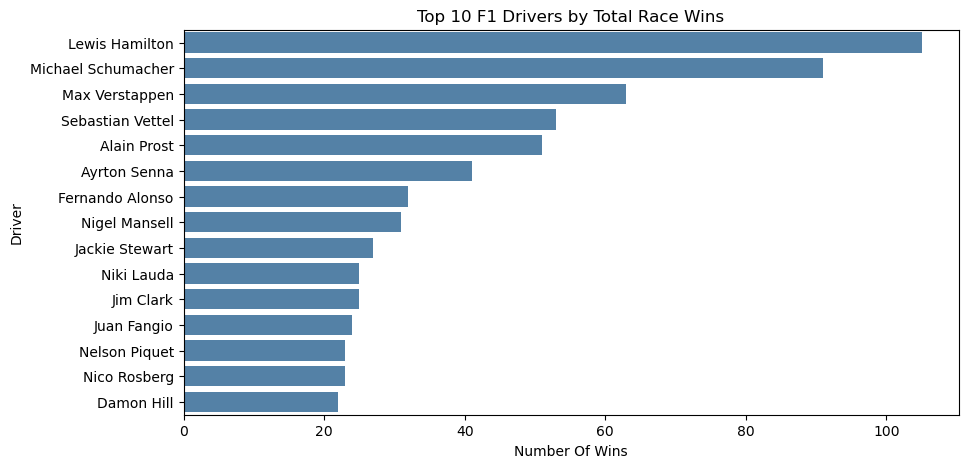

In [57]:
# 1. Filter for 1st place finishers and count by driver 
top_winners = df[df['positionOrder'] == 1]['driver_full_name'].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=top_winners.values, y= top_winners.index, color='steelblue')
plt.title('Top 10 F1 Drivers by Total Race Wins')
plt.xlabel('Number Of Wins')
plt.ylabel('Driver')
plt.show()

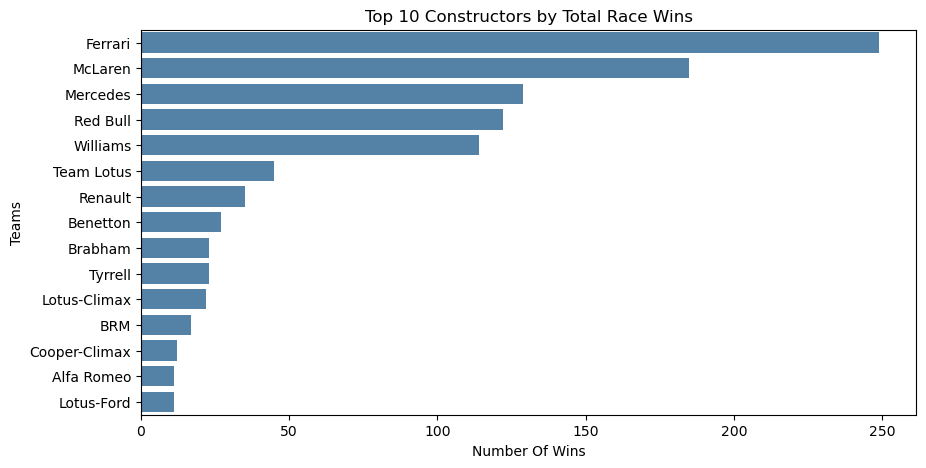

In [58]:
# 2. Filter for Top 10 Constructors by Total Race Wins
top_teams = df[df['positionOrder'] == 1]['name_team'].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=top_teams.values, y= top_teams.index, color='steelblue')
plt.title('Top 10 Constructors by Total Race Wins')
plt.xlabel('Number Of Wins')
plt.ylabel('Teams')
plt.show()

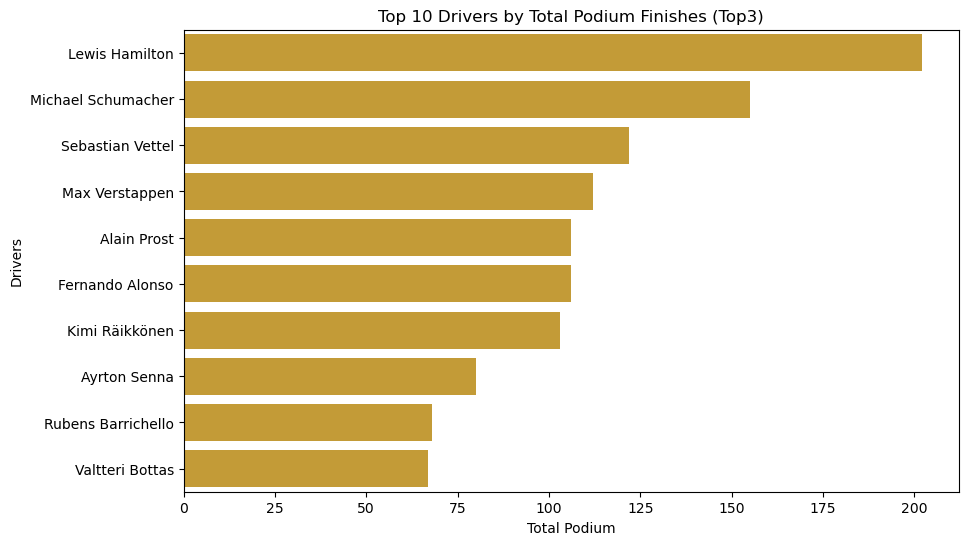

In [59]:
# 3. Filtering Drivers With Most Podium Finsihes (Position 1,2 & 3)

podiums = df[df['positionOrder'] <= 3]['driver_full_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=podiums.values, y=podiums.index, color='goldenrod')
plt.title('Top 10 Drivers by Total Podium Finishes (Top3)')
plt.xlabel('Total Podium')
plt.ylabel('Drivers') 
plt.show()

In [60]:
# Merge status descriptions into df 
df = df.merge(status[['statusId','status']], on='statusId', how='left')

In [61]:
# Verifying the new column
df[['statusId', 'status']].head()

,statusId,status
0,1,Finished
1,1,Finished
2,1,Finished
3,1,Finished
4,1,Finished


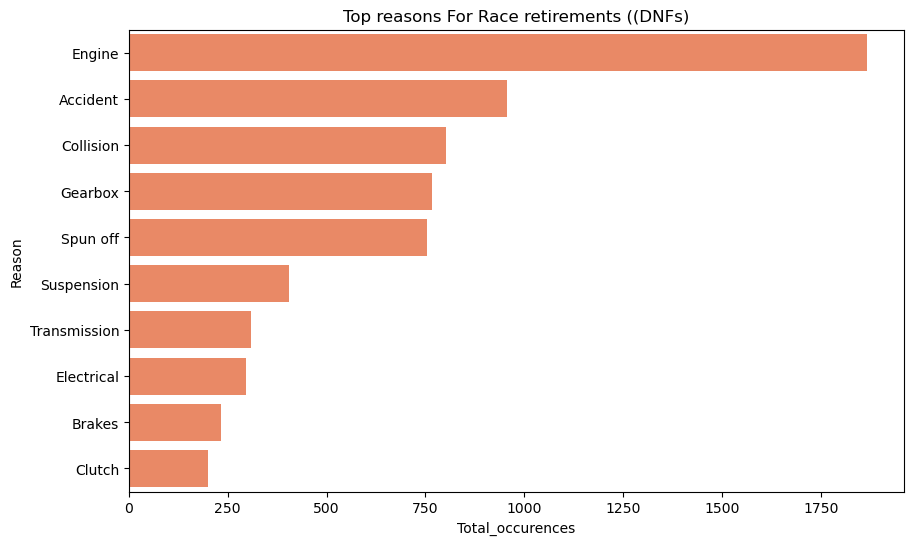

In [62]:
# 4. Filter For retirements and Count the status descriptions 

dnf_causes = df[df['is_dnf']  ==1]['status'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=dnf_causes.values, y=dnf_causes.index,  color='coral')
plt.title('Top reasons For Race retirements ((DNFs)')
plt.xlabel('Total_occurences')
plt.ylabel('Reason')
plt.show()

In [63]:
df.to_csv('fact_race_results.csv', index=False)